In [68]:
import time
import pickle
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy
from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC

In [4]:
from rashomon import quantiles
quantiles.q_mixture_t_root(
                    k=1, w=[1], mu=[2], s=[3], df=[10], prob=0.5
                    )

array([2.])

In [65]:
eps_labels

["r'$\\epsilon$'=0.16",
 "r'$\\epsilon$'=0.17",
 "r'$\\epsilon$'=0.18",
 "r'$\\epsilon$'=0.19",
 "r'$\\epsilon$'=0.2"]

In [75]:
import glob
import pickle

# Scenario-2 final epsilon grid, matching simulation_scenario2_final.py.
epsilons = [0.16, 0.17, 0.18, 0.19, 0.20]
eps_keys = [f"{float(e):g}" for e in epsilons]
eps_labels = [r'$\epsilon$' + f"={float(e):g}" for e in epsilons]

result_paths = sorted(glob.glob("./output2.2/sim2_final_result*.pkl"))
if not result_paths:
    raise FileNotFoundError("No scenario-2 final result files found in ./output2")

data = []
for path in result_paths:
    with open(path, "rb") as f:
        data.extend(pickle.load(f))

print(f"Loaded {len(data)} replications from {len(result_paths)} files")
print("epsilons:", epsilons)


Loaded 50 replications from 10 files
epsilons: [0.16, 0.17, 0.18, 0.19, 0.2]


In [76]:
# Diagnose why PB looks similar to RPS: overlap and posterior mass of PB-added states.
try:
    from rashomon import AIS
except ImportError:
    import sys
    sys.path.insert(0, ".")
    from rashomon import AIS

rows = []
for rep, x in enumerate(data):
    for key in eps_keys:
        rps_states = x[f"RPS_{key}_states"]
        pb_states = x[f"PB_{key}_states"]
        pb_logw = np.asarray(x[f"PB_{key}_logw"], dtype=float)
        rps_sigs = {AIS.state_signature(s) for s in rps_states}
        pb_sigs = [AIS.state_signature(s) for s in pb_states]
        is_old = np.array([sig in rps_sigs for sig in pb_sigs], dtype=bool)
        if len(pb_logw):
            w = np.exp(pb_logw - np.max(pb_logw))
            w = w / np.sum(w)
            new_mass = float(np.sum(w[~is_old]))
        else:
            new_mass = np.nan
        rows.append({
            "rep": rep,
            "eps": float(key),
            "rps_n": len(rps_states),
            "pb_n": len(pb_states),
            "pb_new_n": int(np.sum(~is_old)),
            "pb_new_fraction": float(np.mean(~is_old)) if len(is_old) else np.nan,
            "pb_new_posterior_mass": new_mass,
            "pb_state_fraction_recorded": x.get(f"PB_{key}_state_fraction", np.nan),
        })

pb_overlap = pd.DataFrame(rows)
pb_overlap.groupby("eps")[["rps_n", "pb_n", "pb_new_n", "pb_new_fraction", "pb_new_posterior_mass"]].mean()


,rps_n,pb_n,pb_new_n,pb_new_fraction,pb_new_posterior_mass
eps,,,,,
0.16,67.60,367.60,300.0,0.816132,0.614953
0.17,98.28,398.28,300.0,0.753293,0.533388
0.18,135.48,435.48,300.0,0.688899,0.453695
0.19,150.86,450.86,300.0,0.665397,0.426895
0.20,172.90,472.90,300.0,0.634433,0.395872


Posterior mean plot

In [77]:
import numpy as np
AIS = {k: [] for k in eps_keys}
RPS = {k: [] for k in eps_keys}
PB  = {k: [] for k in eps_keys}

for x in data:
    for key in eps_keys:
        RPS[key].append(np.sum(np.abs(np.asarray(x[f"RPS_{key}"]) - x["MCMC"])))
        AIS[key].append(np.sum(np.abs(np.asarray(x[f"AIS_{key}"]) - x["MCMC"])))
        PB[key].append(np.sum(np.abs(np.asarray(x[f"PB_{key}"])  - x["MCMC"])))


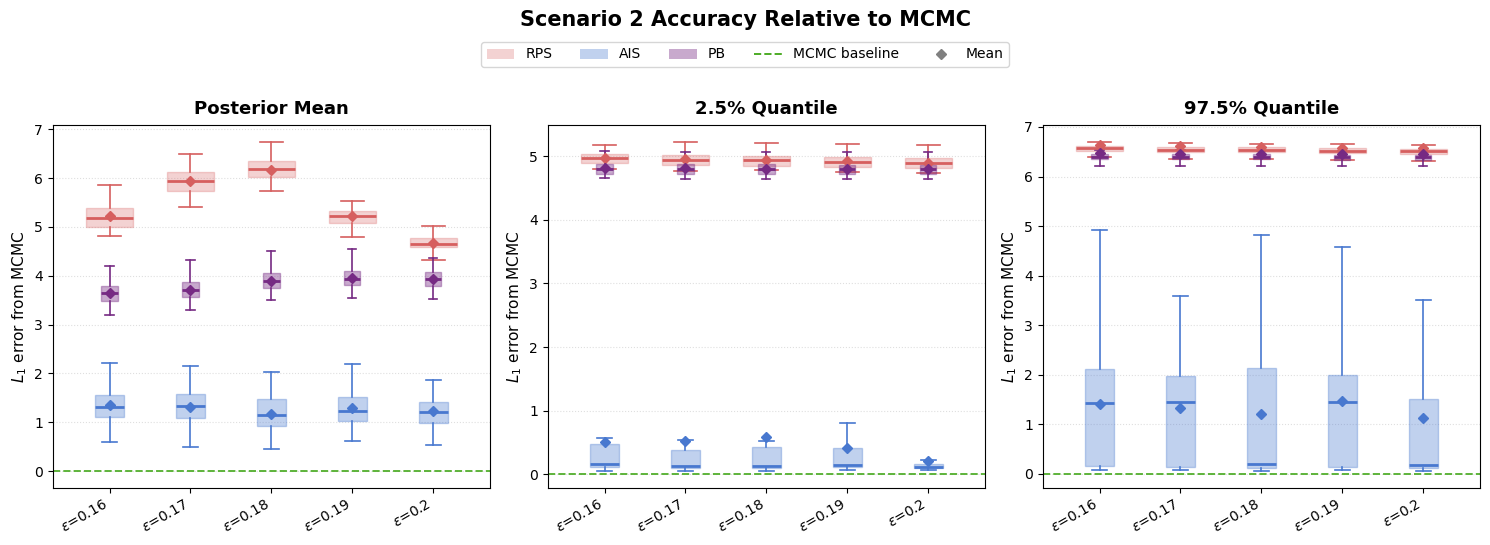

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

AIS_mean = {k: list(v) for k, v in AIS.items()}
RPS_mean = {k: list(v) for k, v in RPS.items()}
PB_mean  = {k: list(v) for k, v in PB.items()}

AIS_q025 = {k: [] for k in eps_keys}
RPS_q025 = {k: [] for k in eps_keys}
PB_q025  = {k: [] for k in eps_keys}
AIS_q975 = {k: [] for k in eps_keys}
RPS_q975 = {k: [] for k in eps_keys}
PB_q975  = {k: [] for k in eps_keys}

for x in data:
    for key in eps_keys:
        AIS_q025[key].append(np.sum(np.abs(x[f"AIS_{key}_quantiles"]["0.025"] - x["MCMC_quantiles"]["0.025"])))
        RPS_q025[key].append(np.sum(np.abs(x[f"RPS_{key}_quantiles"]["0.025"] - x["MCMC_quantiles"]["0.025"])))
        PB_q025[key].append(np.sum(np.abs(x[f"PB_{key}_quantiles"]["0.025"]  - x["MCMC_quantiles"]["0.025"])))
        AIS_q975[key].append(np.sum(np.abs(x[f"AIS_{key}_quantiles"]["0.975"] - x["MCMC_quantiles"]["0.975"])))
        RPS_q975[key].append(np.sum(np.abs(x[f"RPS_{key}_quantiles"]["0.975"] - x["MCMC_quantiles"]["0.975"])))
        PB_q975[key].append(np.sum(np.abs(x[f"PB_{key}_quantiles"]["0.975"]  - x["MCMC_quantiles"]["0.975"])))

def to_df(d):
    df = pd.DataFrame.from_dict(d)
    df.columns = eps_labels
    return df

def aligned_boxplot(ax, values, positions, color, width=0.48, alpha=0.32):
    bp = ax.boxplot(values, positions=positions, widths=width,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color=color, linewidth=2),
                    whiskerprops=dict(color=color, linewidth=1.2),
                    capprops=dict(color=color, linewidth=1.2))
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_edgecolor(color)
        patch.set_alpha(alpha)
    return bp

def mean_diamonds(ax, values, positions, color):
    means = [np.nanmean(v) for v in values]
    ax.plot(positions, means, "D", color=color, markersize=5, linestyle="None", zorder=5)

AIS_mean_df = to_df(AIS_mean)
RPS_mean_df = to_df(RPS_mean)
PB_mean_df  = to_df(PB_mean)
AIS_q025_df = to_df(AIS_q025)
RPS_q025_df = to_df(RPS_q025)
PB_q025_df  = to_df(PB_q025)
AIS_q975_df = to_df(AIS_q975)
RPS_q975_df = to_df(RPS_q975)
PB_q975_df  = to_df(PB_q975)

ais_color  = "#4878CF"
rps_color  = "#D65F5F"
pb_color   = "#762a83"
mcmc_color = "#4DAC26"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
panel_titles = ["Posterior Mean", "2.5% Quantile", "97.5% Quantile"]
ais_dfs = [AIS_mean_df, AIS_q025_df, AIS_q975_df]
rps_dfs = [RPS_mean_df, RPS_q025_df, RPS_q975_df]
pb_dfs  = [PB_mean_df,  PB_q025_df,  PB_q975_df]

n = len(epsilons)
eps_pos = np.arange(1, n + 1)

for ax, title, ais_df, rps_df, pb_df in zip(axes, panel_titles, ais_dfs, rps_dfs, pb_dfs):
    ais_values = [ais_df[col].dropna().values for col in ais_df.columns]
    rps_values = [rps_df[col].dropna().values for col in rps_df.columns]
    pb_values  = [pb_df[col].dropna().values  for col in pb_df.columns]

    aligned_boxplot(ax, rps_values, eps_pos, rps_color, width=0.58, alpha=0.28)
    aligned_boxplot(ax, ais_values, eps_pos, ais_color, width=0.36, alpha=0.34)
    aligned_boxplot(ax, pb_values,  eps_pos, pb_color,  width=0.20, alpha=0.40)
    mean_diamonds(ax, rps_values, eps_pos, rps_color)
    mean_diamonds(ax, ais_values, eps_pos, ais_color)
    mean_diamonds(ax, pb_values,  eps_pos, pb_color)
    ax.axhline(0, color=mcmc_color, linestyle="--", linewidth=1.4, alpha=0.9)

    ax.set_xticks(list(eps_pos))
    ax.set_xticklabels(eps_labels, rotation=30, ha="right", fontsize=10)
    ax.set_xlim(0.3, n + 0.7)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=8)
    ax.set_ylabel("$L_1$ error from MCMC", fontsize=11)
    ax.grid(axis="y", linestyle=":", alpha=0.4)

legend_elements = [
    Patch(facecolor=rps_color, alpha=0.28, label="RPS"),
    Patch(facecolor=ais_color, alpha=0.34, label="AIS"),
    Patch(facecolor=pb_color,  alpha=0.40, label="PB"),
    plt.Line2D([0], [0], color=mcmc_color, linestyle="--", linewidth=1.4, label="MCMC baseline"),
    plt.Line2D([0], [0], marker="D", color="gray", markersize=5, linestyle="None", label="Mean"),
]
fig.legend(handles=legend_elements, loc="upper center", ncol=5, frameon=True, bbox_to_anchor=(0.5, 1.03))
fig.suptitle("Scenario 2 Accuracy Relative to MCMC", fontsize=15, fontweight="bold", y=1.08)
plt.tight_layout()
plt.savefig("../Figures/simulation2_errors.png", dpi=150, bbox_inches="tight")
plt.show()


In [37]:
x[0]["AIS_8.6_time"]

84.42495036125183

Quantile plot

In [56]:
# Quantile plots are consolidated in the combined 3-panel epsilon figure above.


In [ ]:
# Quantile plots are now consolidated in the cell above (posterior mean + 2.5% + 97.5% combined figure)

CI overlap plot

In [79]:
import numpy as np

def ci_overlap_frac(a_m, b_m, a_ref, b_ref):
    intersection = np.maximum(0, np.minimum(b_m, b_ref) - np.maximum(a_m, a_ref))
    ref_len = b_ref - a_ref
    return np.where(ref_len > 0, intersection / ref_len, np.nan)

RPS_overlap = {k: [] for k in eps_keys}
AIS_overlap = {k: [] for k in eps_keys}
PB_overlap  = {k: [] for k in eps_keys}

for x in data:
    mcmc_lo = x['MCMC_quantiles']['0.025']
    mcmc_hi = x['MCMC_quantiles']['0.975']
    for key in eps_keys:
        rps_lo = x[f'RPS_{key}_quantiles']['0.025']; rps_hi = x[f'RPS_{key}_quantiles']['0.975']
        ais_lo = x[f'AIS_{key}_quantiles']['0.025']; ais_hi = x[f'AIS_{key}_quantiles']['0.975']
        pb_lo  = x[f'PB_{key}_quantiles']['0.025'];  pb_hi  = x[f'PB_{key}_quantiles']['0.975']
        RPS_overlap[key].append(np.nanmean(ci_overlap_frac(rps_lo, rps_hi, mcmc_lo, mcmc_hi)))
        AIS_overlap[key].append(np.nanmean(ci_overlap_frac(ais_lo, ais_hi, mcmc_lo, mcmc_hi)))
        PB_overlap[key].append(np.nanmean(ci_overlap_frac(pb_lo,  pb_hi,  mcmc_lo, mcmc_hi)))


/var/folders/8z/m4kbswp17qq4hy08by5m6m800000gn/T/ipykernel_26106/2101558686.py:44: RuntimeWarning: Mean of empty slice
  means = [np.nanmean(v) for v in values]
/var/folders/8z/m4kbswp17qq4hy08by5m6m800000gn/T/ipykernel_26106/2101558686.py:44: RuntimeWarning: Mean of empty slice
  means = [np.nanmean(v) for v in values]
/var/folders/8z/m4kbswp17qq4hy08by5m6m800000gn/T/ipykernel_26106/3287261568.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.22, 1, 1])


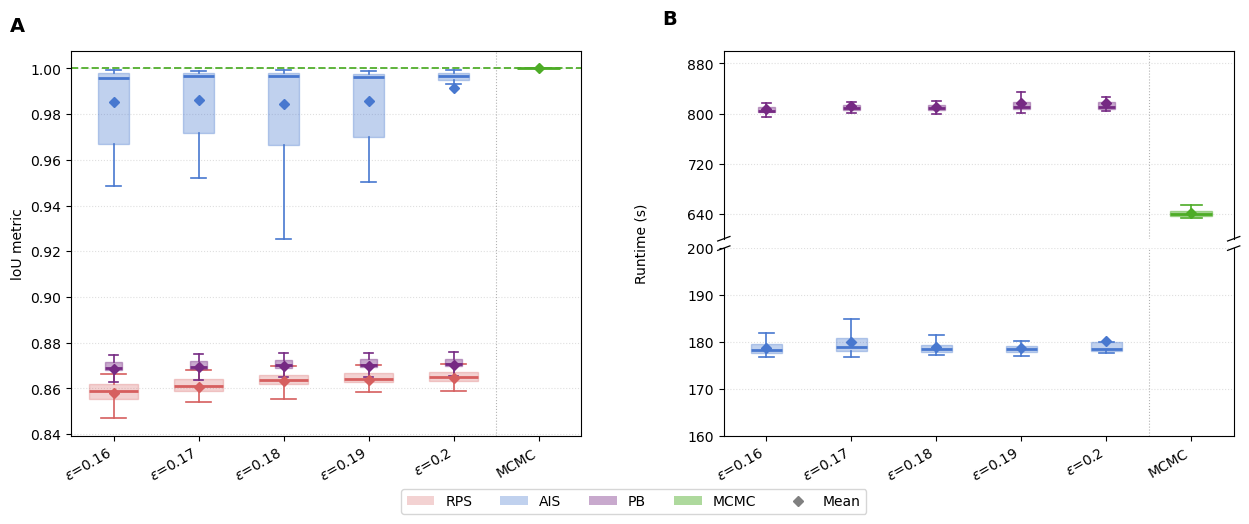

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

cols = eps_keys
x_pos = np.arange(len(cols))
mcmc_pos = [len(cols)]

RPS_time = {k: [] for k in eps_keys}
AIS_time = {k: [] for k in eps_keys}
PB_time  = {k: [] for k in eps_keys}
MCMC_time = []
for x in data:
    mcmc_t = x.get("MCMC_time", np.nan)
    MCMC_time.append(mcmc_t if np.isfinite(mcmc_t) and mcmc_t > 0 else np.nan)
    for key in eps_keys:
        for target, field in [
            (RPS_time, f"RPS_{key}_time"),
            (AIS_time, f"AIS_{key}_time"),
            (PB_time,  f"PB_{key}_time"),
        ]:
            val = x.get(field, np.nan)
            target[key].append(val if np.isfinite(val) and val > 0 else np.nan)

method_time_values = np.array([
    v
    for store in (RPS_time, AIS_time, PB_time)
    for key in eps_keys
    for v in store[key]
    if np.isfinite(v) and v > 0
])
ais_time_values = np.array([
    v
    for key in eps_keys
    for v in AIS_time[key]
    if np.isfinite(v) and v > 0
])
pb_time_values = np.array([
    v
    for key in eps_keys
    for v in PB_time[key]
    if np.isfinite(v) and v > 0
])
mcmc_time_values = np.array([v for v in MCMC_time if np.isfinite(v) and v > 0])

# Linear broken axis: break starts just above AIS so PB/MCMC keep readable values.
all_time_values = np.concatenate([
    arr for arr in (method_time_values, mcmc_time_values) if len(arr)
]) if (len(method_time_values) or len(mcmc_time_values)) else np.array([])
ais_top = np.nanmax(ais_time_values) if len(ais_time_values) else np.nanmax(method_time_values)
low_min = 160.0
low_max = 200
above_break_values = all_time_values[all_time_values > low_max] if len(all_time_values) else np.array([])
high_min = 600.0
high_max = 900.0

fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.28)
ax_ci = fig.add_subplot(gs[0, 0])
time_gs = gs[0, 1].subgridspec(2, 1, height_ratios=[1, 1], hspace=0.05)
ax_time_high = fig.add_subplot(time_gs[0, 0])
ax_time_low = fig.add_subplot(time_gs[1, 0], sharex=ax_time_high)

ax_ci.text(-0.12, 1.04, 'A', transform=ax_ci.transAxes, fontsize=14, fontweight='bold', va='bottom')
ax_time_high.text(-0.12, 1.12, 'B', transform=ax_time_high.transAxes, fontsize=14, fontweight='bold', va='bottom')

# CI overlap with MCMC baseline.
aligned_boxplot(ax_ci, [RPS_overlap[c] for c in cols], x_pos, rps_color, width=0.58, alpha=0.28)
aligned_boxplot(ax_ci, [AIS_overlap[c] for c in cols], x_pos, ais_color, width=0.36, alpha=0.34)
aligned_boxplot(ax_ci, [PB_overlap[c]  for c in cols], x_pos, pb_color,  width=0.20, alpha=0.40)
aligned_boxplot(ax_ci, [np.ones(len(data))], mcmc_pos, mcmc_color, width=0.50, alpha=0.45)
mean_diamonds(ax_ci, [RPS_overlap[c] for c in cols], x_pos, rps_color)
mean_diamonds(ax_ci, [AIS_overlap[c] for c in cols], x_pos, ais_color)
mean_diamonds(ax_ci, [PB_overlap[c]  for c in cols], x_pos, pb_color)
mean_diamonds(ax_ci, [np.ones(len(data))], mcmc_pos, mcmc_color)
ax_ci.axhline(1.0, color=mcmc_color, linestyle='--', linewidth=1.4, alpha=0.9)
ax_ci.axvline(len(cols) - 0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
ax_ci.set_xticks(list(x_pos) + mcmc_pos)
ax_ci.set_xticklabels(eps_labels + ['MCMC'], rotation=30, ha='right')
ax_ci.set_ylabel('loU metric')
ax_ci.grid(axis='y', linestyle=':', alpha=0.4)

def plot_runtime_axis(ax):
    aligned_boxplot(ax, [RPS_time[k] for k in eps_keys], x_pos, rps_color, width=0.58, alpha=0.28)
    aligned_boxplot(ax, [AIS_time[k] for k in eps_keys], x_pos, ais_color, width=0.36, alpha=0.34)
    aligned_boxplot(ax, [PB_time[k]  for k in eps_keys], x_pos, pb_color,  width=0.20, alpha=0.40)
    aligned_boxplot(ax, [MCMC_time], mcmc_pos, mcmc_color, width=0.50, alpha=0.45)
    mean_diamonds(ax, [RPS_time[k] for k in eps_keys], x_pos, rps_color)
    mean_diamonds(ax, [AIS_time[k] for k in eps_keys], x_pos, ais_color)
    mean_diamonds(ax, [PB_time[k]  for k in eps_keys], x_pos, pb_color)
    mean_diamonds(ax, [MCMC_time], mcmc_pos, mcmc_color)
    ax.axvline(len(cols) - 0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.grid(axis='y', linestyle=':', alpha=0.4)

plot_runtime_axis(ax_time_high)
plot_runtime_axis(ax_time_low)
ax_time_high.set_ylim(high_min, high_max)
ax_time_low.set_ylim(low_min, low_max)
ax_time_high.yaxis.set_major_locator(plt.MaxNLocator(4))
ax_time_low.yaxis.set_major_locator(plt.MaxNLocator(4))

ax_time_high.spines['bottom'].set_visible(False)
ax_time_low.spines['top'].set_visible(False)
ax_time_high.tick_params(labelbottom=False, bottom=False)
ax_time_low.set_xticks(list(x_pos) + mcmc_pos)
ax_time_low.set_xticklabels(eps_labels + ['MCMC'], rotation=30, ha='right')
ax_time_low.set_ylabel('')

# Centered y-label for the full broken-axis time panel.
fig.canvas.draw_idle()
time_pos_high = ax_time_high.get_position()
time_pos_low = ax_time_low.get_position()
fig.text(
    time_pos_low.x0 - 0.055,
    (time_pos_low.y0 + time_pos_high.y1) / 2,
    'Runtime (s)',
    rotation=90,
    va='center',
    ha='center',
)

# Diagonal marks for the broken y-axis.
d = 0.012
kwargs = dict(transform=ax_time_high.transAxes, color='k', clip_on=False, linewidth=0.9)
ax_time_high.plot((-d, +d), (-d, +d), **kwargs)
ax_time_high.plot((1 - d, 1 + d), (-d, +d), **kwargs)
kwargs.update(transform=ax_time_low.transAxes)
ax_time_low.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_time_low.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

legend_elements = [
    mpatches.Patch(facecolor=rps_color, alpha=0.28, label='RPS'),
    mpatches.Patch(facecolor=ais_color, alpha=0.34, label='AIS'),
    mpatches.Patch(facecolor=pb_color,  alpha=0.40, label='PB'),
    mpatches.Patch(facecolor=mcmc_color, alpha=0.45, label='MCMC'),
    plt.Line2D([0], [0], marker='D', color='gray', markersize=5, linestyle='None', label='Mean'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, frameon=True, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout(rect=[0, 0.22, 1, 1])
plt.savefig('../Figures/simulation2_ci_overlap_time.png', dpi=150, bbox_inches='tight')
plt.show()


Hausdorff distance and scaled Wasserstein decomposition

In [60]:
import numpy as np

def hausdorff(lo_m, hi_m, lo_ref, hi_ref):
    return np.maximum(np.abs(lo_m - lo_ref), np.abs(hi_m - hi_ref))

def scaled_wasserstein(lo_m, hi_m, lo_ref, hi_ref):
    m = (lo_m + hi_m) / 2; w = (hi_m - lo_m) / 2
    m_ref = (lo_ref + hi_ref) / 2; w_ref = (hi_ref - lo_ref) / 2
    loc = ((m - m_ref) / w_ref) ** 2
    scale = ((w - w_ref) / w_ref) ** 2
    return loc + scale

HD_RPS = {k: [] for k in eps_keys}
HD_AIS = {k: [] for k in eps_keys}
HD_PB  = {k: [] for k in eps_keys}
SW_RPS = {k: [] for k in eps_keys}
SW_AIS = {k: [] for k in eps_keys}
SW_PB  = {k: [] for k in eps_keys}

for x in data:
    lo_mc = x['MCMC_quantiles']['0.025']; hi_mc = x['MCMC_quantiles']['0.975']
    for key in eps_keys:
        lo_r = x[f'RPS_{key}_quantiles']['0.025']; hi_r = x[f'RPS_{key}_quantiles']['0.975']
        lo_a = x[f'AIS_{key}_quantiles']['0.025']; hi_a = x[f'AIS_{key}_quantiles']['0.975']
        lo_p = x[f'PB_{key}_quantiles']['0.025'];  hi_p = x[f'PB_{key}_quantiles']['0.975']
        HD_RPS[key].append(np.mean(hausdorff(lo_r, hi_r, lo_mc, hi_mc)))
        HD_AIS[key].append(np.mean(hausdorff(lo_a, hi_a, lo_mc, hi_mc)))
        HD_PB[key].append(np.mean(hausdorff(lo_p, hi_p, lo_mc, hi_mc)))
        SW_RPS[key].append(np.mean(scaled_wasserstein(lo_r, hi_r, lo_mc, hi_mc)))
        SW_AIS[key].append(np.mean(scaled_wasserstein(lo_a, hi_a, lo_mc, hi_mc)))
        SW_PB[key].append(np.mean(scaled_wasserstein(lo_p, hi_p, lo_mc, hi_mc)))


In [51]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def side_by_side_boxplot(ax, rps_dict, ais_dict, pb_dict, title, ylabel):
    cols = list(rps_dict.keys())
    x_pos = np.arange(len(cols))
    aligned_boxplot(ax, [rps_dict[c] for c in cols], x_pos, rps_color, width=0.58, alpha=0.28)
    aligned_boxplot(ax, [ais_dict[c] for c in cols], x_pos, ais_color, width=0.36, alpha=0.34)
    aligned_boxplot(ax, [pb_dict[c]  for c in cols], x_pos, pb_color,  width=0.20, alpha=0.40)
    mean_diamonds(ax, [rps_dict[c] for c in cols], x_pos, rps_color)
    mean_diamonds(ax, [ais_dict[c] for c in cols], x_pos, ais_color)
    mean_diamonds(ax, [pb_dict[c]  for c in cols], x_pos, pb_color)
    ax.axhline(0.0, color=mcmc_color, linestyle='--', linewidth=1.4, alpha=0.9)
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(eps_labels, rotation=30, ha='right')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', linestyle=':', alpha=0.4)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
side_by_side_boxplot(axes[0], HD_RPS, HD_AIS, HD_PB,
    'Hausdorff Distance to MCMC 95% CI
max(|lo-lo_MCMC|, |hi-hi_MCMC|), mean over policies',
    'Hausdorff distance to MCMC (lower = better)')
side_by_side_boxplot(axes[1], SW_RPS, SW_AIS, SW_PB,
    'Scaled Wasserstein Decomposition vs MCMC
((m-m_MCMC)/w_MCMC)² + ((w-w_MCMC)/w_MCMC)², mean over policies',
    'Scaled distance to MCMC (lower = better)')
legend_elements = [
    mpatches.Patch(facecolor=rps_color, alpha=0.28, label='RPS'),
    mpatches.Patch(facecolor=ais_color, alpha=0.34, label='AIS'),
    mpatches.Patch(facecolor=pb_color,  alpha=0.40, label='PB'),
    plt.Line2D([0],[0], color=mcmc_color, linestyle='--', linewidth=1.4, label='MCMC baseline'),
    plt.Line2D([0],[0], marker='D', color='gray', markersize=6, linestyle='None', label='Mean'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.savefig('../Figures/simulation2_ci_distances.png', dpi=150, bbox_inches='tight')
plt.show()


SyntaxError: unterminated string literal (detected at line 22) (1269214035.py, line 22)

time plot

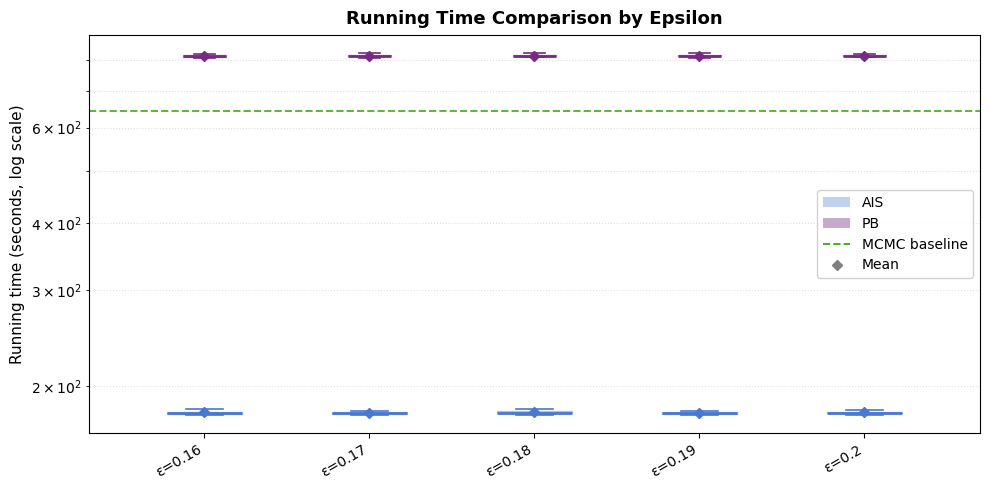

In [22]:
# CI-overlap and runtime plots are combined in the cell above.


In [50]:
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy
from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC
lamb=1
theta=8.6
M = 2
R = np.array([4, 3])

num_profiles = 2**M
profiles, profile_map = hasse.enumerate_profiles(M)

all_policies = hasse.enumerate_policies(M, R)
num_policies = len(all_policies)

sigma_00 = None
mu_00 = np.array([0])
# mu_00 = np.array([5])
var_00 = np.array([1])

# Profile (0, 1)
sigma_01 = np.array([[1]])
mu_01 = np.array([-1])
# mu_01 = np.array([10])
var_01 = np.array([1])

# Profile (1, 0)
sigma_10 = np.array([[1, 0]])
mu_10 = np.array([-2, -3])
# mu_10 = np.array([-10, 15])
var_10 = np.array([1, 1])

# Profile (1, 1)
sigma_11 = np.array([[0, 1], [0, np.inf]])
mu_11 = np.array([2, 3, -1, 1])
# mu_11 = np.array([20, 30, 5, 10])
var_11 = np.array([1, 1, 1, 1])

sigma = [sigma_00, sigma_01, sigma_10, sigma_11]
mu = [mu_00, mu_01, mu_10, mu_11]
var = [var_00, var_01, var_10, var_11]

policies_profiles = {}
policies_profiles_masked = {}
policies_ids_profiles = {}
pi_policies = {}
pi_pools = {}
for k, profile in enumerate(profiles):

    policies_temp = [(i, x) for i, x in enumerate(all_policies) if hasse.policy_to_profile(x) == profile]
    unzipped_temp = list(zip(*policies_temp))
    policies_ids_k = list(unzipped_temp[0])
    policies_k = list(unzipped_temp[1])
    policies_profiles[k] = deepcopy(policies_k)
    policies_ids_profiles[k] = policies_ids_k

    profile_mask = list(map(bool, profile))

    # Mask the empty arms
    for idx, pol in enumerate(policies_k):
        policies_k[idx] = tuple([pol[i] for i in range(M) if profile_mask[i]])
    policies_profiles_masked[k] = policies_k

    if np.sum(profile) > 0:
        pi_pools_k, pi_policies_k = extract_pools.extract_pools(policies_k, sigma[k])
        if len(pi_pools_k.keys()) != mu[k].shape[0]:
            print(f"Profile {k}. Expected {len(pi_pools_k.keys())} pools. Received {mu[k].shape[0]} means.")
        pi_policies[k] = pi_policies_k
        # pi_pools_k has indicies that match with policies_profiles[k]
        # Need to map those indices back to all_policies
        pi_pools[k] = {}
        for x, y in pi_pools_k.items():
            y_full = [policies_profiles[k][i] for i in y]
            y_agg = [all_policies.index(i) for i in y_full]
            pi_pools[k][x] = y_agg
    else:
        pi_policies[k] = {0: 0}
        pi_pools[k] = {0: [0]}

def generate_data(mu, var, n_per_pol, all_policies, pi_policies, M):
    num_data = num_policies * n_per_pol
    X = np.zeros(shape=(num_data, M))
    D = np.zeros(shape=(num_data, 1), dtype='int_')
    y = np.zeros(shape=(num_data, 1))

    idx_ctr = 0
    for k, profile in enumerate(profiles):
        policies_k = policies_profiles[k]

        for idx, policy in enumerate(policies_k):
            policy_idx = [i for i, x in enumerate(all_policies) if x == policy]

            pool_id = pi_policies[k][idx]
            mu_i = mu[k][pool_id]
            var_i = var[k][pool_id]
            y_i = np.random.normal(mu_i, var_i, size=(n_per_pol, 1))

            start_idx = idx_ctr * n_per_pol
            end_idx = (idx_ctr + 1) * n_per_pol

            X[start_idx:end_idx, ] = policy
            D[start_idx:end_idx, ] = policy_idx[0]
            y[start_idx:end_idx, ] = y_i

            idx_ctr += 1

    return X, D, y

num_samples_per_feature = 500
length = []
X, D, y = generate_data(mu, var, num_samples_per_feature, all_policies, pi_policies, M)
policy_means = loss.compute_policy_means(D, y, num_policies)
prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)
# for iter in range(1,51):
#     np.random.seed(iter*42)
#     X, D, y = generate_data(mu, var, num_samples_per_feature, all_policies, pi_policies, M)
#     policy_means = loss.compute_policy_means(D, y, num_policies)
#     prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)

#     def score_s(state):
#                 Q = AIS.global_loss_raw(
#                     state=state,
#                     D=D, y=y, M=M, R=R,
#                     prof_idx_of_policy = prof_idx_of_policy,
#                     policies=all_policies,
#                     policy_means=policy_means,
#                     reg=lamb, normalize=0,
#                     lattice_edges=None,
#                 )
#                 return float(np.exp(-Q))

#     H = np.inf
#     R_set, R_profiles = aggregate.RAggregate(M, R, H, D, y, theta, reg=lamb, verbose=True)

#     anchors = AIS.build_anchor_states(R_set, R_profiles, M, R)
#     prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)

#     RPS_states = AIS.raggregate_to_states((R_set, R_profiles), profiles)
#     length.append(len(RPS_states))


In [110]:
np.min(length)

np.int64(27)

In [85]:
prob = [score_s(A) for A in RPS_states]

In [63]:
ais_out = AIS.run_ais_streaming_from_data(
                M, 
                R, 
                H, 
                D, 
                y, 
                theta, 
                reg=lamb,
                eps1=0.5,
                eps2=0.75,
                all_policies=all_policies,
                score_s=score_s,
                out_dir="./output_files",
                cfg = cfg,
            )

(0, 0) 7.713983213235162
Profile (0, 0) has 1 objects in Rashomon set
(0, 1) 7.787866083122113
Adaptive
Profile (0, 1) took 0.002752065658569336 s adaptively
Profile (0, 1) has 2 objects in Rashomon set
(1, 0) 7.861153034821504
Adaptive
Profile (1, 0) took 0.003144979476928711 s adaptively
Profile (1, 0) has 4 objects in Rashomon set
(1, 1) 8.129868070487802
Adaptive
Profile (1, 1) took 0.013110160827636719 s adaptively
Profile (1, 1) has 8 objects in Rashomon set
Finding feasible combinations
Min = 6.104129726871667, Max = 12.96904319944447
Running pilot adaptive ladder
Adaptive ladder has 6 levels; first 10: [0.   0.05 0.15 0.35 0.75 1.  ]
Per-step ESS ratios (len = 5 ): [1.0, 0.9913673317344911, 0.9661198469626824, 0.9435768657754946, 0.9865325923648947]


In [25]:
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import rashomon
importlib.reload(rashomon.MCMC)

from copy import deepcopy
from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC
# mcmc_res = MCMC.load_mcmc_res_from_jsonl("./output_files/mcmc_samples1.jsonl")

# log_weight = np.log(np.repeat(1/len(mcmc_res["samples"]), len(mcmc_res["samples"])))

start = time.time()
mcmc_summ2 = MCMC.quantiles_for_all_policies(
    mcmc_res["samples"],
    log_weight,
    D, y,                     # D[:,0] = global policy id; y is (N,) or (N,1)
    M,
    all_policies,                 # global policies list (len P)
    prof_idx_of_policy,       # length-P array: global policy id -> profile k
    R,                    # per-arm levels (len M)
    lattice_edges=None,
    mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=2.0,
    p=[0.025,0.5,0.975], 
    seed=None
)
end = time.time()
print(end-start)

# start = time.time()
# mcmc_summ = MCMC.quantiles_for_all_policies_root(
#     mcmc_res["samples"],
#     log_weight,
#     D, y,                     # D[:,0] = global policy id; y is (N,) or (N,1)
#     M,
#     all_policies,                 # global policies list (len P)
#     prof_idx_of_policy,       # length-P array: global policy id -> profile k
#     R,                    # per-arm levels (len M)
#     lattice_edges=None,
#     mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=2.0,
#     p=[0.025,0.5,0.975], 
#     seed=None
# )
# end = time.time()
# print(end-start)

57.30595302581787


Check number of rung in temperature ladder

In [40]:
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy
from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC

lamb=1

M = 3
R = np.array([4, 3, 3])

num_profiles = 2**M
profiles, profile_map = hasse.enumerate_profiles(M)

all_policies = hasse.enumerate_policies(M, R)
num_policies = len(all_policies)

# Profile (0, 0, 0)
sigma_000 = None
mu_000 = np.array([0])
var_000 = np.array([1])

# Profile (0, 0, 1)
sigma_001 = np.array([[1]])
mu_001 = np.array([-2])
var_001 = np.array([1])

# Profile (0, 1, 0)
sigma_010 = np.array([[1]])
mu_010 = np.array([-1.5])
var_010 = np.array([1])

# Profile (0, 1, 1)
sigma_011 = np.array([[1], [0]])
mu_011 = np.array([-1, 2])
var_011 = np.array([1, 1])

# Profile (1, 0, 0)
sigma_100 = np.array([[0, 1]])
mu_100 = np.array([-1.5, 1])
var_100 = np.array([1, 1])

# Profile (1, 0, 1)
sigma_101 = np.array([[0, 1], [0, np.inf]])
mu_101 = np.array([-0.5, 2.5, 1.5, -2.5])
var_101 = np.array([1, 1, 1, 1])

# Profile (1, 1, 0)
sigma_110 = np.array([[0, 1], [1, np.inf]])
mu_110 = np.array([0, -2.5])
var_110 = np.array([1, 1])

# Profile (1, 1, 1)
sigma_111 = np.array([[0, 1], [1, np.inf], [0, np.inf]])
mu_111 = np.array([3, -0.5, -1.5, -2])
var_111 = np.array([1, 1, 1, 1])

sigma = [sigma_000, sigma_001, sigma_010, sigma_011,
            sigma_100, sigma_101, sigma_110, sigma_111]

mu = [mu_000, mu_001, mu_010, mu_011,
        mu_100, mu_101, mu_110, mu_111]

var = [var_000, var_001, var_010, var_011,
        var_100, var_101, var_110, var_111]

policies_profiles = {}
policies_profiles_masked = {}
policies_ids_profiles = {}
pi_policies = {}
pi_pools = {}
if 1==1:
    for k, profile in enumerate(profiles):

        policies_temp = [(i, x) for i, x in enumerate(all_policies) if hasse.policy_to_profile(x) == profile]
        unzipped_temp = list(zip(*policies_temp))
        policies_ids_k = list(unzipped_temp[0])
        policies_k = list(unzipped_temp[1])
        policies_profiles[k] = deepcopy(policies_k)
        policies_ids_profiles[k] = policies_ids_k

        profile_mask = list(map(bool, profile))

        # Mask the empty arms
        for idx, pol in enumerate(policies_k):
            policies_k[idx] = tuple([pol[i] for i in range(M) if profile_mask[i]])
        policies_profiles_masked[k] = policies_k

        if np.sum(profile) > 0:
            pi_pools_k, pi_policies_k = extract_pools.extract_pools(policies_k, sigma[k])
            if len(pi_pools_k.keys()) != mu[k].shape[0]:
                print(f"Profile {k}. Expected {len(pi_pools_k.keys())} pools. Received {mu[k].shape[0]} means.")
            pi_policies[k] = pi_policies_k
            # pi_pools_k has indicies that match with policies_profiles[k]
            # Need to map those indices back to all_policies
            pi_pools[k] = {}
            for x, y in pi_pools_k.items():
                y_full = [policies_profiles[k][i] for i in y]
                y_agg = [all_policies.index(i) for i in y_full]
                pi_pools[k][x] = y_agg
        else:
            pi_policies[k] = {0: 0}
            pi_pools[k] = {0: [0]}

    def generate_data(mu, var, n_per_pol, all_policies, pi_policies, M):
        num_data = num_policies * n_per_pol
        X = np.zeros(shape=(num_data, M))
        D = np.zeros(shape=(num_data, 1), dtype='int_')
        y = np.zeros(shape=(num_data, 1))

        idx_ctr = 0
        for k, profile in enumerate(profiles):
            policies_k = policies_profiles[k]

            for idx, policy in enumerate(policies_k):
                policy_idx = [i for i, x in enumerate(all_policies) if x == policy]

                pool_id = pi_policies[k][idx]
                mu_i = mu[k][pool_id]
                var_i = var[k][pool_id]
                y_i = np.random.normal(mu_i, var_i, size=(n_per_pol, 1))

                start_idx = idx_ctr * n_per_pol
                end_idx = (idx_ctr + 1) * n_per_pol

                X[start_idx:end_idx, ] = policy
                D[start_idx:end_idx, ] = policy_idx[0]
                y[start_idx:end_idx, ] = y_i

                idx_ctr += 1

        return X, D, y

X, D, y = generate_data(mu, var, 500, all_policies, pi_policies, M)
policy_means = loss.compute_policy_means(D, y, num_policies)
prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)

In [41]:
for theta in [13, 13.1, 13.2, 13.3, 13.4]:
    H = np.inf
    R_set, R_profiles = aggregate.RAggregate(M, R, H, D, y, theta, reg=lamb, verbose=True)
    print(len(R_set))

python(78353) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(78354) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


(0, 0, 0) 12.025350088462211
Profile (0, 0, 0) has 1 objects in Rashomon set
(0, 0, 1) 12.051797402778933
Adaptive
Profile (0, 0, 1) took 0.0014638900756835938 s adaptively
Profile (0, 0, 1) has 2 objects in Rashomon set
(0, 1, 0) 12.048348699849232
Adaptive
Profile (0, 1, 0) took 0.0014183521270751953 s adaptively
Profile (0, 1, 0) has 2 objects in Rashomon set
(0, 1, 1) 12.107021617581937
Adaptive
Profile (0, 1, 1) took 0.0042688846588134766 s adaptively
Profile (0, 1, 1) has 4 objects in Rashomon set
(1, 0, 0) 12.079574541048009
Adaptive
Profile (1, 0, 0) took 0.0030219554901123047 s adaptively
Profile (1, 0, 0) has 4 objects in Rashomon set
(1, 0, 1) 12.159464257298108
Adaptive
Profile (1, 0, 1) took 0.013206005096435547 s adaptively
Profile (1, 0, 1) has 8 objects in Rashomon set
(1, 1, 0) 12.16559810559546
Adaptive
Profile (1, 1, 0) took 0.012627124786376953 s adaptively
Profile (1, 1, 0) has 8 objects in Rashomon set
(1, 1, 1) 12.327634925200371
Adaptive
Profile (1, 1, 1) took 0

python(78355) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


(0, 0, 0) 12.125350088462211
Profile (0, 0, 0) has 1 objects in Rashomon set
(0, 0, 1) 12.151797402778932
Adaptive
Profile (0, 0, 1) took 0.0014529228210449219 s adaptively
Profile (0, 0, 1) has 2 objects in Rashomon set
(0, 1, 0) 12.148348699849231
Adaptive
Profile (0, 1, 0) took 0.0011570453643798828 s adaptively
Profile (0, 1, 0) has 2 objects in Rashomon set
(0, 1, 1) 12.207021617581937
Adaptive
Profile (0, 1, 1) took 0.0047190189361572266 s adaptively
Profile (0, 1, 1) has 4 objects in Rashomon set
(1, 0, 0) 12.179574541048009
Adaptive
Profile (1, 0, 0) took 0.003035306930541992 s adaptively
Profile (1, 0, 0) has 4 objects in Rashomon set
(1, 0, 1) 12.259464257298108
Adaptive
Profile (1, 0, 1) took 0.01299905776977539 s adaptively
Profile (1, 0, 1) has 8 objects in Rashomon set
(1, 1, 0) 12.26559810559546
Adaptive
Profile (1, 1, 0) took 0.012581825256347656 s adaptively
Profile (1, 1, 0) has 8 objects in Rashomon set
(1, 1, 1) 12.42763492520037
Adaptive
Profile (1, 1, 1) took 0.05

python(78356) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


(0, 0, 0) 12.22535008846221
Profile (0, 0, 0) has 1 objects in Rashomon set
(0, 0, 1) 12.251797402778932
Adaptive
Profile (0, 0, 1) took 0.0017070770263671875 s adaptively
Profile (0, 0, 1) has 2 objects in Rashomon set
(0, 1, 0) 12.248348699849231
Adaptive
Profile (0, 1, 0) took 0.0013370513916015625 s adaptively
Profile (0, 1, 0) has 2 objects in Rashomon set
(0, 1, 1) 12.307021617581936
Adaptive
Profile (0, 1, 1) took 0.005359649658203125 s adaptively
Profile (0, 1, 1) has 4 objects in Rashomon set
(1, 0, 0) 12.279574541048008
Adaptive
Profile (1, 0, 0) took 0.004223823547363281 s adaptively
Profile (1, 0, 0) has 4 objects in Rashomon set
(1, 0, 1) 12.359464257298107
Adaptive
Profile (1, 0, 1) took 0.014415264129638672 s adaptively
Profile (1, 0, 1) has 8 objects in Rashomon set
(1, 1, 0) 12.36559810559546
Adaptive
Profile (1, 1, 0) took 0.013602733612060547 s adaptively
Profile (1, 1, 0) has 8 objects in Rashomon set
(1, 1, 1) 12.52763492520037
Adaptive
Profile (1, 1, 1) took 0.057

python(78357) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


(0, 0, 0) 12.325350088462212
Profile (0, 0, 0) has 1 objects in Rashomon set
(0, 0, 1) 12.351797402778933
Adaptive
Profile (0, 0, 1) took 0.0014579296112060547 s adaptively
Profile (0, 0, 1) has 2 objects in Rashomon set
(0, 1, 0) 12.348348699849232
Adaptive
Profile (0, 1, 0) took 0.0016269683837890625 s adaptively
Profile (0, 1, 0) has 2 objects in Rashomon set
(0, 1, 1) 12.407021617581938
Adaptive
Profile (0, 1, 1) took 0.004544973373413086 s adaptively
Profile (0, 1, 1) has 4 objects in Rashomon set
(1, 0, 0) 12.37957454104801
Adaptive
Profile (1, 0, 0) took 0.0033311843872070312 s adaptively
Profile (1, 0, 0) has 4 objects in Rashomon set
(1, 0, 1) 12.459464257298109
Adaptive
Profile (1, 0, 1) took 0.013617992401123047 s adaptively
Profile (1, 0, 1) has 8 objects in Rashomon set
(1, 1, 0) 12.465598105595461
Adaptive
Profile (1, 1, 0) took 0.013623952865600586 s adaptively
Profile (1, 1, 0) has 8 objects in Rashomon set
(1, 1, 1) 12.627634925200372
Adaptive
Profile (1, 1, 1) took 0.

python(78358) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


(0, 0, 0) 12.425350088462212
Profile (0, 0, 0) has 1 objects in Rashomon set
(0, 0, 1) 12.451797402778933
Adaptive
Profile (0, 0, 1) took 0.0015430450439453125 s adaptively
Profile (0, 0, 1) has 2 objects in Rashomon set
(0, 1, 0) 12.448348699849232
Adaptive
Profile (0, 1, 0) took 0.0014181137084960938 s adaptively
Profile (0, 1, 0) has 2 objects in Rashomon set
(0, 1, 1) 12.507021617581938
Adaptive
Profile (0, 1, 1) took 0.004302978515625 s adaptively
Profile (0, 1, 1) has 4 objects in Rashomon set
(1, 0, 0) 12.47957454104801
Adaptive
Profile (1, 0, 0) took 0.0033559799194335938 s adaptively
Profile (1, 0, 0) has 4 objects in Rashomon set
(1, 0, 1) 12.559464257298108
Adaptive
Profile (1, 0, 1) took 0.012829065322875977 s adaptively
Profile (1, 0, 1) has 8 objects in Rashomon set
(1, 1, 0) 12.56559810559546
Adaptive
Profile (1, 1, 0) took 0.012698888778686523 s adaptively
Profile (1, 1, 0) has 8 objects in Rashomon set
(1, 1, 1) 12.727634925200372
Adaptive
Profile (1, 1, 1) took 0.0523